# V6 Capstone — one Graph emits scores + diagnostic panels

This notebook demonstrates D15: a single `Graph` consumes prediction + reference Datasets and emits **both** numerical scores and validation panels as terminal outputs. Closes the V6 epic.

1. Synthetic SSH twin (truth + noisy + smoothed predictions).
2. Compute V1 score: `SkillByLeadTime`.
3. Compute a 1-D PSD-style spectral score (synthetic for the demo).
4. Build a single `Graph` whose terminal nodes include both score Datasets and `LeadTimeSkillPanel` / `SpectralSkillPanel` / `ScaleSkillPanel`.
5. Bonus: V6.4 `EventVerificationPanel` driven by hand-authored event masks (V5 detectors are stubs in this branch).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from xrtoolz import Graph, Input
from xrtoolz.metrics import RMSE, SkillByLeadTime
from xrtoolz.viz.validation import (
    LeadTimeSkillPanel,
    ScaleSkillPanel,
    SpectralSkillPanel,
    EventVerificationPanel,
)

## 1 — Synthetic SSH twin

In [2]:
rng = np.random.default_rng(0)
lead = np.arange(7)
lon = np.linspace(-30, 30, 41)
lat = np.linspace(20, 50, 31)
LON, LAT = np.meshgrid(lon, lat, indexing='xy')
truth_field = 0.1 * np.sin(np.deg2rad(2*LON)) * np.cos(np.deg2rad(LAT))
truth = np.broadcast_to(truth_field, (lead.size,) + truth_field.shape)
noise = rng.normal(0.0, 0.01 * (1 + lead[:, None, None] * 0.4), size=truth.shape)
pred = truth + noise
ds_pred = xr.Dataset({'ssh': (('lead_time', 'lat', 'lon'), pred)},
                     coords={'lead_time': lead, 'lat': lat, 'lon': lon})
ds_ref  = xr.Dataset({'ssh': (('lead_time', 'lat', 'lon'), truth)},
                     coords={'lead_time': lead, 'lat': lat, 'lon': lon})
ds_pred

<xarray.Dataset> Size: 72kB
Dimensions:    (lead_time: 7, lat: 31, lon: 41)
Coordinates:
  * lead_time  (lead_time) int64 56B 0 1 2 3 4 5 6
  * lat        (lat) float64 248B 20.0 21.0 22.0 23.0 ... 47.0 48.0 49.0 50.0
  * lon        (lon) float64 328B -30.0 -28.5 -27.0 -25.5 ... 27.0 28.5 30.0
Data variables:
    ssh        (lead_time, lat, lon) float64 71kB -0.08012 ... -0.008556

## 2 — V1 SkillByLeadTime via a Graph emitting scores **and** a panel

scores:
<xarray.DataArray 'ssh' (lead_time: 7)> Size: 56B
array([0.00981676, 0.01419666, 0.01789138, 0.02184858, 0.02589836,
       0.03086421, 0.03383007])
Coordinates:
  * lead_time  (lead_time) int64 56B 0 1 2 3 4 5 6


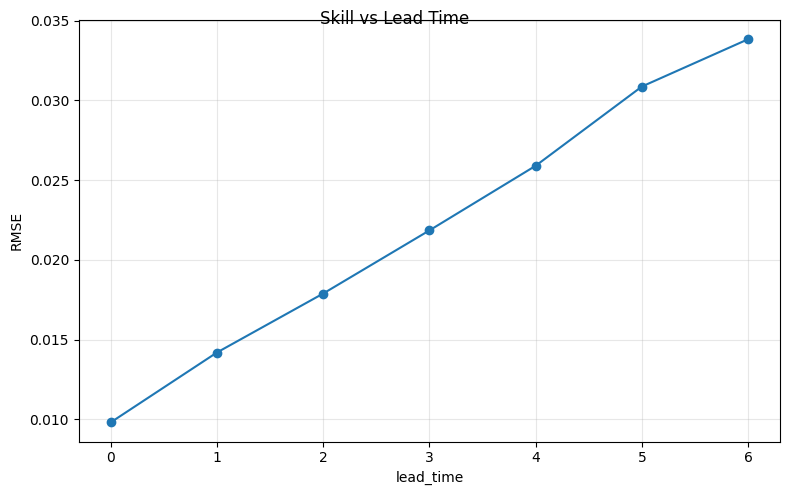

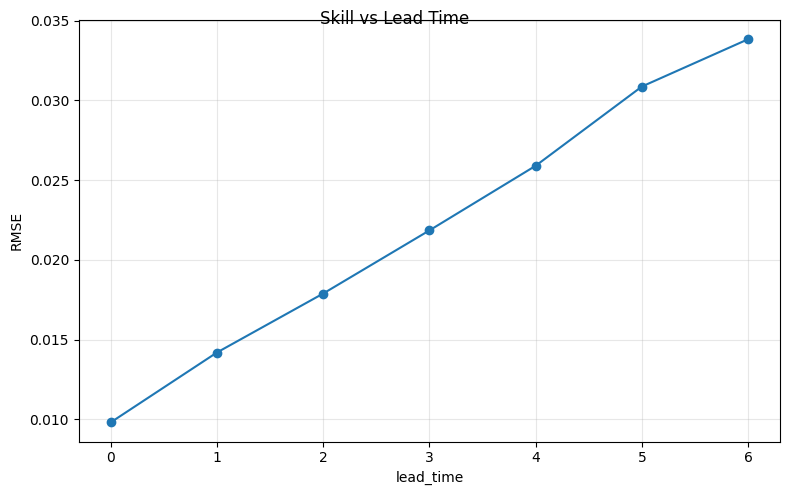

In [3]:
rmse = RMSE('ssh', dims=('lat', 'lon'))
skill_op = SkillByLeadTime(metric=rmse, lead_dim='lead_time')
panel_op = LeadTimeSkillPanel(lead_dim='lead_time', ylabel='RMSE')

pred_in = Input(name='pred')
ref_in  = Input(name='ref')
scores_node = skill_op(pred_in, ref_in)
panel_node  = panel_op(scores_node)

g = Graph(inputs={'pred': pred_in, 'ref': ref_in},
          outputs={'scores': scores_node, 'panel': panel_node})
out = g(pred=ds_pred, ref=ds_ref)
print('scores:'); print(out['scores'])
out['panel']

## 3 — Spectral skill panel (1-D synthetic score)

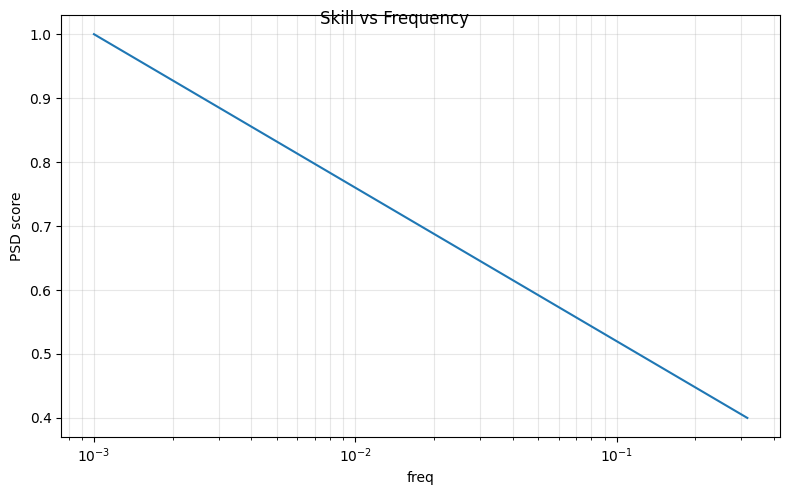

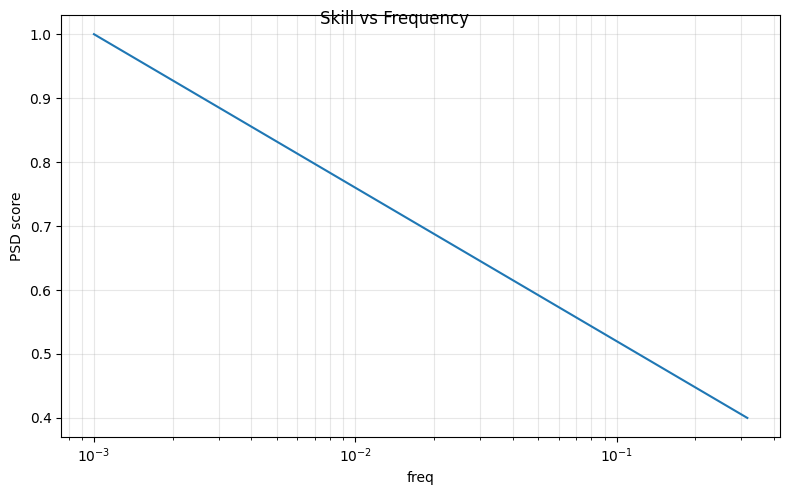

In [4]:
freq = np.logspace(-3, -0.5, 30)
psd_score = np.clip(1 - 0.6 * (np.log10(freq) - np.log10(freq.min())) / (np.log10(freq.max()) - np.log10(freq.min())), 0, 1)
scores_da = xr.DataArray(psd_score, coords={'freq': freq}, dims=('freq',), name='psd_score')
spec_panel = SpectralSkillPanel(freq_dim='freq', log_x=True)
spec_panel(scores_da)

## 4 — Region skill panel

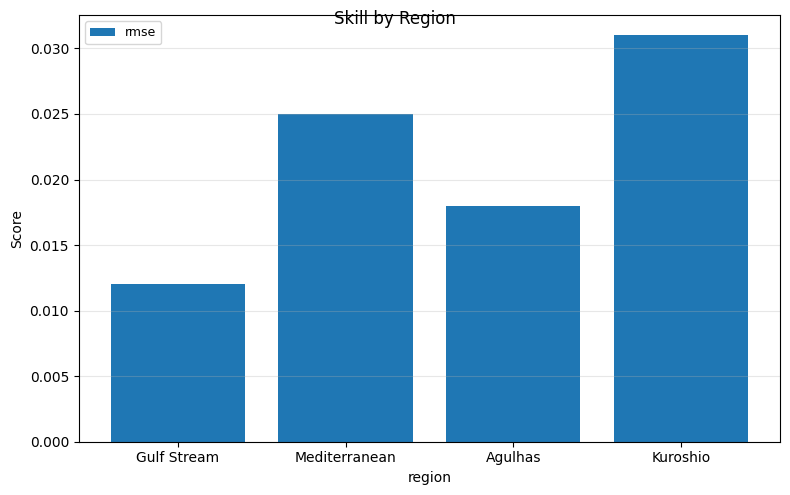

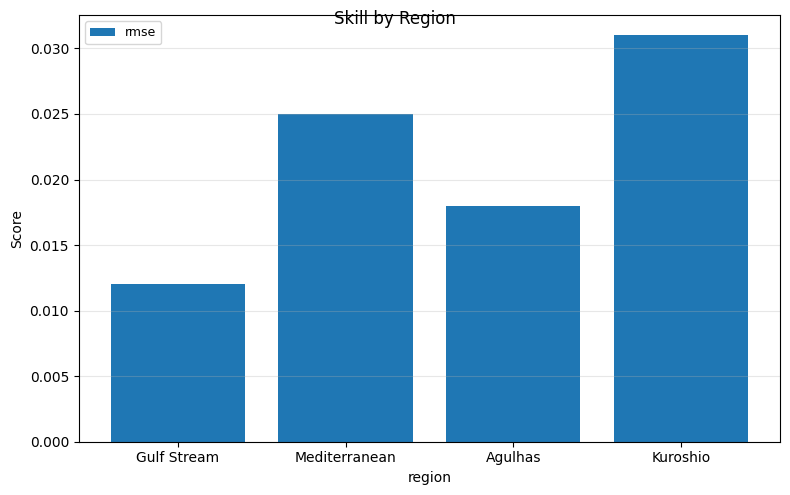

In [5]:
region_scores = xr.Dataset(
    {'rmse': ('region', [0.012, 0.025, 0.018, 0.031])},
    coords={'region': ['Gulf Stream', 'Mediterranean', 'Agulhas', 'Kuroshio']},
)
ScaleSkillPanel(region_dim='region', metric='rmse')(region_scores)

## 5 — Event verification panel (synthetic)

V5 detectors land in a future PR; the panel is fixture-driven here to demonstrate the V6.4 contract.

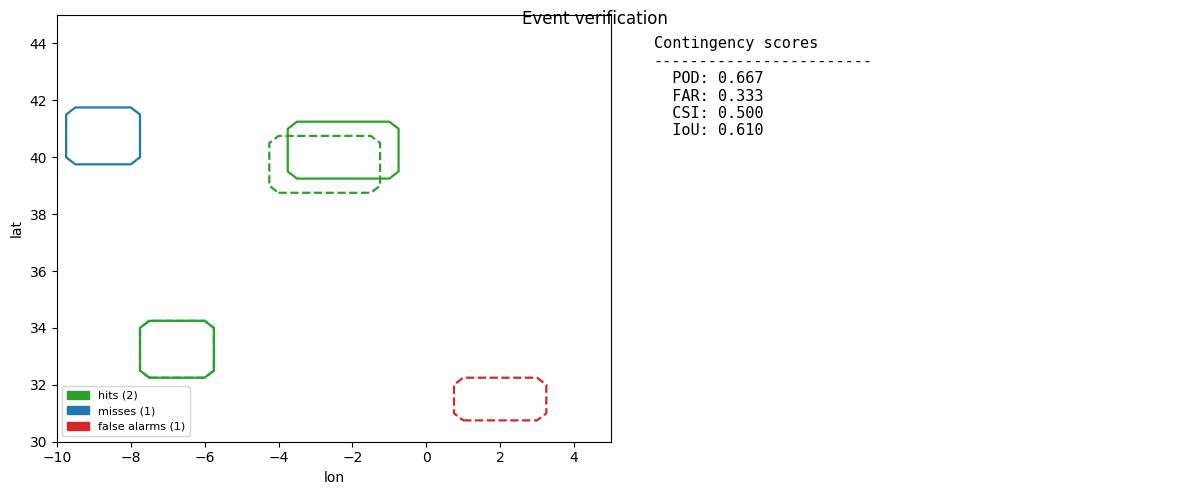

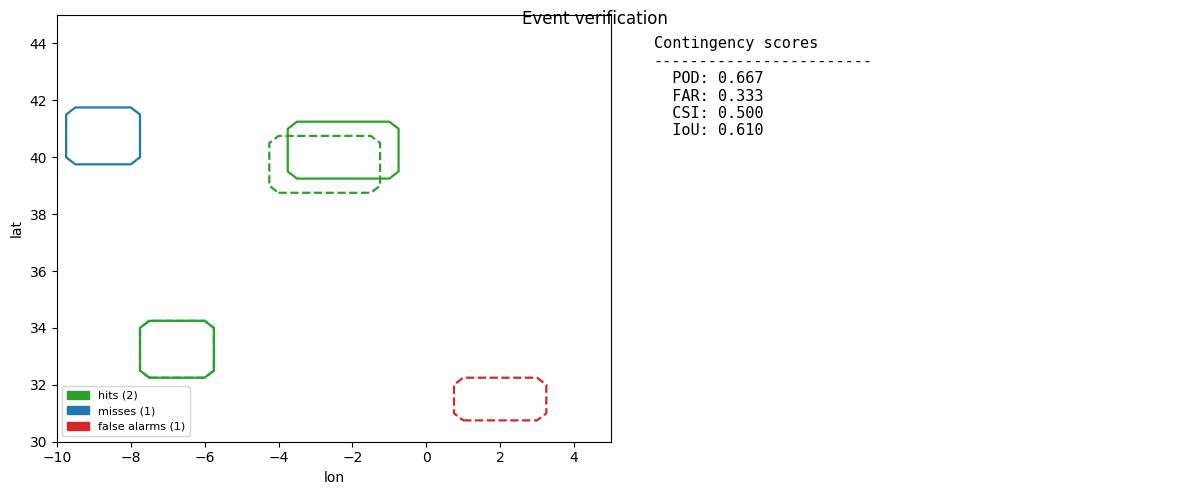

In [6]:
lon_e = np.linspace(-10, 5, 31)
lat_e = np.linspace(30, 45, 31)
pred_grid = np.zeros((lat_e.size, lon_e.size), dtype=int)
pred_grid[5:9, 5:9] = 1
pred_grid[18:22, 12:18] = 2
pred_grid[2:5, 22:27] = 3
ref_grid = np.zeros_like(pred_grid)
ref_grid[5:9, 5:9] = 10
ref_grid[19:23, 13:19] = 20
ref_grid[20:24, 1:5] = 30
objects_pred = xr.Dataset({'label': (('lat','lon'), pred_grid)}, coords={'lat': lat_e, 'lon': lon_e})
objects_ref  = xr.Dataset({'label': (('lat','lon'), ref_grid)},  coords={'lat': lat_e, 'lon': lon_e})
matches = {'hits': [(1, 10), (2, 20)], 'false_alarms': [3], 'misses': [30]}
scores = {'POD': 2/3, 'FAR': 1/3, 'CSI': 0.5, 'IoU': 0.61}
EventVerificationPanel(use_cartopy=False)(objects_pred, objects_ref, matches, scores)